In [1]:
# =========================================================
# 03_baselines.ipynb
# Purpose:
#   - Load final cleaned dataset
#   - Create train/validation/test splits
#   - Train baseline ML models:
#       • Logistic Regression
#       • Linear SVM
#   - Evaluate performance
# =========================================================

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported.")

Libraries imported.


In [3]:
ML_ROOT = Path.cwd().parent

FINAL_DATA_DIR = ML_ROOT / "data" / "final"

final_dataset_path = FINAL_DATA_DIR / "sentiment_dataset_final.csv"

print("Dataset path:", final_dataset_path)

Dataset path: C:\Users\hp\Lucidia-project\ml\data\final\sentiment_dataset_final.csv


In [4]:
df = pd.read_csv(final_dataset_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (11492, 5)


,text,label,label_raw,source_dataset,text_length_chars
0,استفيدوا من عروض جازي عايلة الجديدة لي توالم ك...,1,0.0,dataset_1,340
1,Conx ta3koum dayra ki lhaaaam w say,0,-1.0,dataset_1,35
2,@zaki_medjber_62,1,0.0,dataset_1,16
3,ما فهمتش هي sim وحدة يخدمو بها العائلة كاملة,1,0.0,dataset_1,44
4,🙏😉🙏,2,1.0,dataset_1,3


In [5]:
print(df["label"].value_counts().sort_index())

label
0    4687
1    4971
2    1834
Name: count, dtype: int64


In [6]:
X = df["text"]
y = df["label"]

In [7]:
# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 8044
Validation size: 1724
Test size: 1724


In [8]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (8044, 10000)


In [9]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_tfidf, y_train)

y_val_pred_lr = log_reg.predict(X_val_tfidf)

In [10]:
print("Logistic Regression Results:\n")

print("Accuracy:", accuracy_score(y_val, y_val_pred_lr))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_lr))

Logistic Regression Results:

Accuracy: 0.5968677494199536

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.61      0.61       703
           1       0.56      0.66      0.61       746
           2       0.77      0.39      0.52       275

    accuracy                           0.60      1724
   macro avg       0.64      0.55      0.58      1724
weighted avg       0.61      0.60      0.59      1724



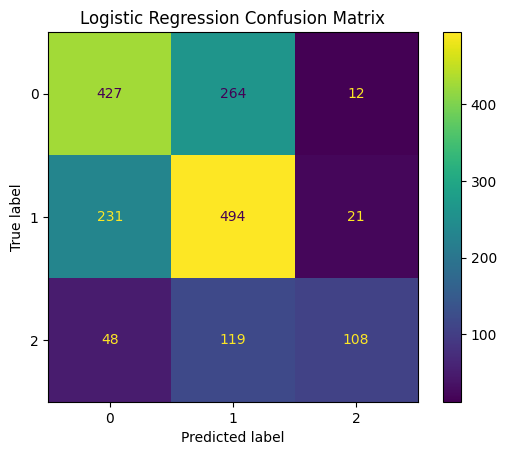

In [11]:
cm = confusion_matrix(y_val, y_val_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [12]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_val_pred_svm = svm_model.predict(X_val_tfidf)

In [13]:
print("SVM Results:\n")

print("Accuracy:", accuracy_score(y_val, y_val_pred_svm))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_svm))

SVM Results:

Accuracy: 0.5823665893271461

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.58      0.58       703
           1       0.56      0.63      0.59       746
           2       0.66      0.47      0.55       275

    accuracy                           0.58      1724
   macro avg       0.60      0.56      0.57      1724
weighted avg       0.59      0.58      0.58      1724



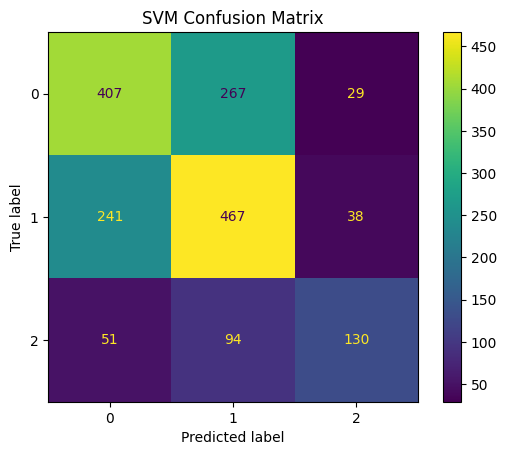

In [14]:
cm = confusion_matrix(y_val, y_val_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [15]:

best_model = log_reg  

y_test_pred = best_model.predict(X_test_tfidf)

print("Final Test Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Final Test Performance:

Accuracy: 0.6160092807424594

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63       703
           1       0.59      0.68      0.63       746
           2       0.73      0.38      0.50       275

    accuracy                           0.62      1724
   macro avg       0.65      0.57      0.59      1724
weighted avg       0.63      0.62      0.61      1724



In [16]:
results = {
    "logistic_accuracy": float(accuracy_score(y_val, y_val_pred_lr)),
    "svm_accuracy": float(accuracy_score(y_val, y_val_pred_svm))
}

print(results)

{'logistic_accuracy': 0.5968677494199536, 'svm_accuracy': 0.5823665893271461}
